# EDA de sepsis

Este notebook deja el **análisis exploratorio** separado en dos momentos:

- **antes del preprocesado e imputación**, usando la base inicial;
- **después del preprocesado e imputación**, usando la base preparada para modelado.

El objetivo es describir la estructura de los datos, su distribución y su relación con la mortalidad hospitalaria. Para centrar el análisis, se priorizan las variables clínicas y analíticas que la documentación del proyecto señala como más relevantes para la fase posterior de modelado.

In [20]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

In [21]:
RAW_PATH = Path("bbdd") / "Supplementary Table 1. APSIII.csv"
IMPUTED_PATH = Path("bbdd") / "BaseDatos_imputada_knn.csv"

TARGET_COL = "hospital_expire_flag"
POST_OUTCOME_COLUMNS = [
    "deathoffset",
    "unitdischargeoffset",
    "hospitaldischargeoffset",
    "los_icu",
    "los_hospital",
]

def sniff_csv_format(path: Path) -> tuple[str, str]:
    with path.open("r", encoding="utf-8", errors="ignore") as handle:
        header = handle.readline()
    if header.count(";") > header.count(","):
        return ";", ","
    return ",", "."

def load_dataset(path: Path) -> pd.DataFrame:
    sep, decimal = sniff_csv_format(path)
    df = pd.read_csv(path, sep=sep, decimal=decimal)
    unnamed = [col for col in df.columns if str(col).startswith("Unnamed")]
    if unnamed:
        df = df.rename(columns={unnamed[0]: "Unnamed: 0"})
    return df

raw_df = load_dataset(RAW_PATH)
imputed_df = load_dataset(IMPUTED_PATH)

## 1. Visión general de las dos bases

Antes de analizar variables concretas, comprobamos tamaño, número de columnas y proporción de mortalidad en cada versión de la base. En este caso, la base pre y la base post representan dos etapas consecutivas del pipeline y mantienen una cohorte muy similar, aunque no exactamente idéntica, por lo que la comparación pre/post sí resulta metodológicamente útil para describir el efecto del preprocesado y la imputación.

In [22]:
overview = pd.DataFrame(
    [
        {
            "dataset": "pre_imputacion",
            "n_filas": raw_df.shape[0],
            "n_columnas": raw_df.shape[1],
            "mortalidad": raw_df[TARGET_COL].mean() if TARGET_COL in raw_df.columns else np.nan,
        },
        {
            "dataset": "post_imputacion",
            "n_filas": imputed_df.shape[0],
            "n_columnas": imputed_df.shape[1],
            "mortalidad": imputed_df[TARGET_COL].mean() if TARGET_COL in imputed_df.columns else np.nan,
        },
    ]
)

display(overview)

print(
    f"Diferencia de tamaño entre bases: {raw_df.shape[0] - imputed_df.shape[0]} registros. "
    "La cohorte es muy parecida, aunque no totalmente idéntica."
)


,dataset,n_filas,n_columnas,mortalidad
0,pre_imputacion,53569,72,0.102746
1,post_imputacion,53493,55,0.101490


Diferencia de tamaño entre bases: 76 registros. La cohorte es muy parecida, aunque no totalmente idéntica.


## 2. Selección de variables de interés

Para no dispersar el EDA sobre todas las columnas, se priorizan las variables clínicas y de laboratorio que hemos identificado como relevantes para la fase posterior de modelado:

- variables demográficas y de ingreso;
- scores de gravedad y disfunción;
- signos vitales;
- parámetros de laboratorio;
- escala de Glasgow y variables relacionadas.

También excluimos de la interpretación clínica inicial las columnas claramente posteriores al desenlace o al alta.

In [23]:
documentation_selected_vars = [
    "gender",
    "admission_age",
    "ethnicity",
    "admission_type",
    "admission_location",
    "marital_status",
    "gcs_unable",
    "sepsis3",
    "apsiii",
    "apsiii_prob",
    "hr_score",
    "mbp_score",
    "temp_score",
    "resp_rate_score",
    "hematocrit_score",
    "wbc_score",
    "creatinine_score",
    "uo_score",
    "bun_score",
    "sodium_score",
    "glucose_score",
    "gcs_score",
    "heart_rate_max",
    "heart_rate_min",
    "mbp_min",
    "mbp_max",
    "temperature_min",
    "temperature_max",
    "resp_rate_min",
    "resp_rate_max",
    "hematocrit_min",
    "hematocrit_max",
    "wbc_min",
    "wbc_max",
    "creatinine_min",
    "creatinine_max",
    "bun_min",
    "bun_max",
    "sodium_min",
    "sodium_max",
    "glucose_min",
    "glucose_max",
    "urineoutput",
    "gcs_eyes",
    "gcs_verbal",
    "gcs_motor",
]

categorical_vars = [
    "gender",
    "ethnicity",
    "admission_type",
    "admission_location",
    "marital_status",
    "gcs_unable",
    "sepsis3",
]

ordinal_vars = ["gcs_eyes", "gcs_verbal", "gcs_motor", "gcs_score"]

focus_numeric_vars = [
    "admission_age",
    "apsiii",
    "apsiii_prob",
    "heart_rate_max",
    "heart_rate_min",
    "mbp_min",
    "mbp_max",
    "temperature_max",
    "resp_rate_max",
    "creatinine_max",
    "bun_max",
    "glucose_max",
    "urineoutput",
    "gcs_score",
]

selected_vars = [
    col for col in documentation_selected_vars
    if col in raw_df.columns or col in imputed_df.columns
]

raw_selected = [col for col in selected_vars if col in raw_df.columns]
imputed_selected = [col for col in selected_vars if col in imputed_df.columns]

variable_map = pd.DataFrame(
    {
        "variable": selected_vars,
        "en_pre_imputacion": [var in raw_df.columns for var in selected_vars],
        "en_post_imputacion": [var in imputed_df.columns for var in selected_vars],
        "tipo": [
            "categorica" if var in categorical_vars
            else "ordinal" if var in ordinal_vars
            else "numerica"
            for var in selected_vars
        ],
    }
)

display(variable_map.head(20))

,variable,en_pre_imputacion,en_post_imputacion,tipo
0,gender,True,True,categorica
1,admission_age,True,True,numerica
2,ethnicity,True,True,categorica
3,admission_type,True,True,categorica
4,admission_location,True,True,categorica
5,marital_status,True,True,categorica
6,gcs_unable,True,True,categorica
7,sepsis3,True,True,categorica
8,apsiii,True,True,numerica
9,apsiii_prob,True,True,numerica


## 3. EDA antes del preprocesado e imputación

En esta parte trabajamos con la base inicial. Nos interesa revisar:

- estructura general y calidad del dato;
- distribuciones univariantes;
- relaciones bivariantes con la variable objetivo y entre variables clínicas.

In [24]:
raw_missing = (
    raw_df[raw_selected]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "variable"})
)

raw_missing.head(15)

,variable,missing_pct
0,sepsis3,0.557468
1,marital_status,0.086916
2,temp_score,0.032295
3,temperature_min,0.032295
4,temperature_max,0.032295
5,uo_score,0.030167
6,urineoutput,0.030167
7,gcs_score,0.021598
8,sodium_score,0.011873
9,sodium_min,0.011873


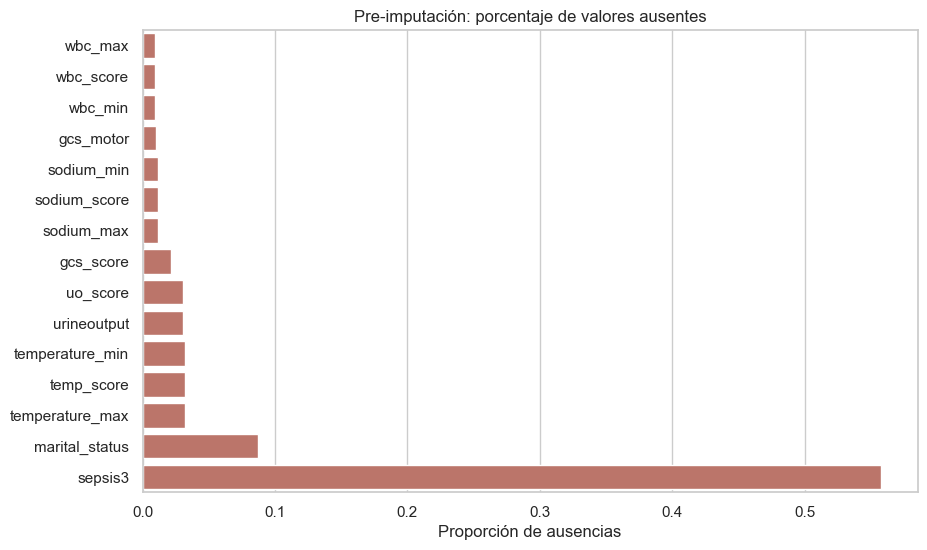

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=raw_missing.head(15).sort_values("missing_pct", ascending=True),
    x="missing_pct",
    y="variable",
    color="#c96b5c",
)
plt.title("Pre-imputación: porcentaje de valores ausentes")
plt.xlabel("Proporción de ausencias")
plt.ylabel("")
plt.show()

### 3.1 Análisis univariante en la base pre-imputación

Primero observamos de forma separada variables categóricas y numéricas para entender frecuencias, asimetrías, dispersión y posibles valores extremos.

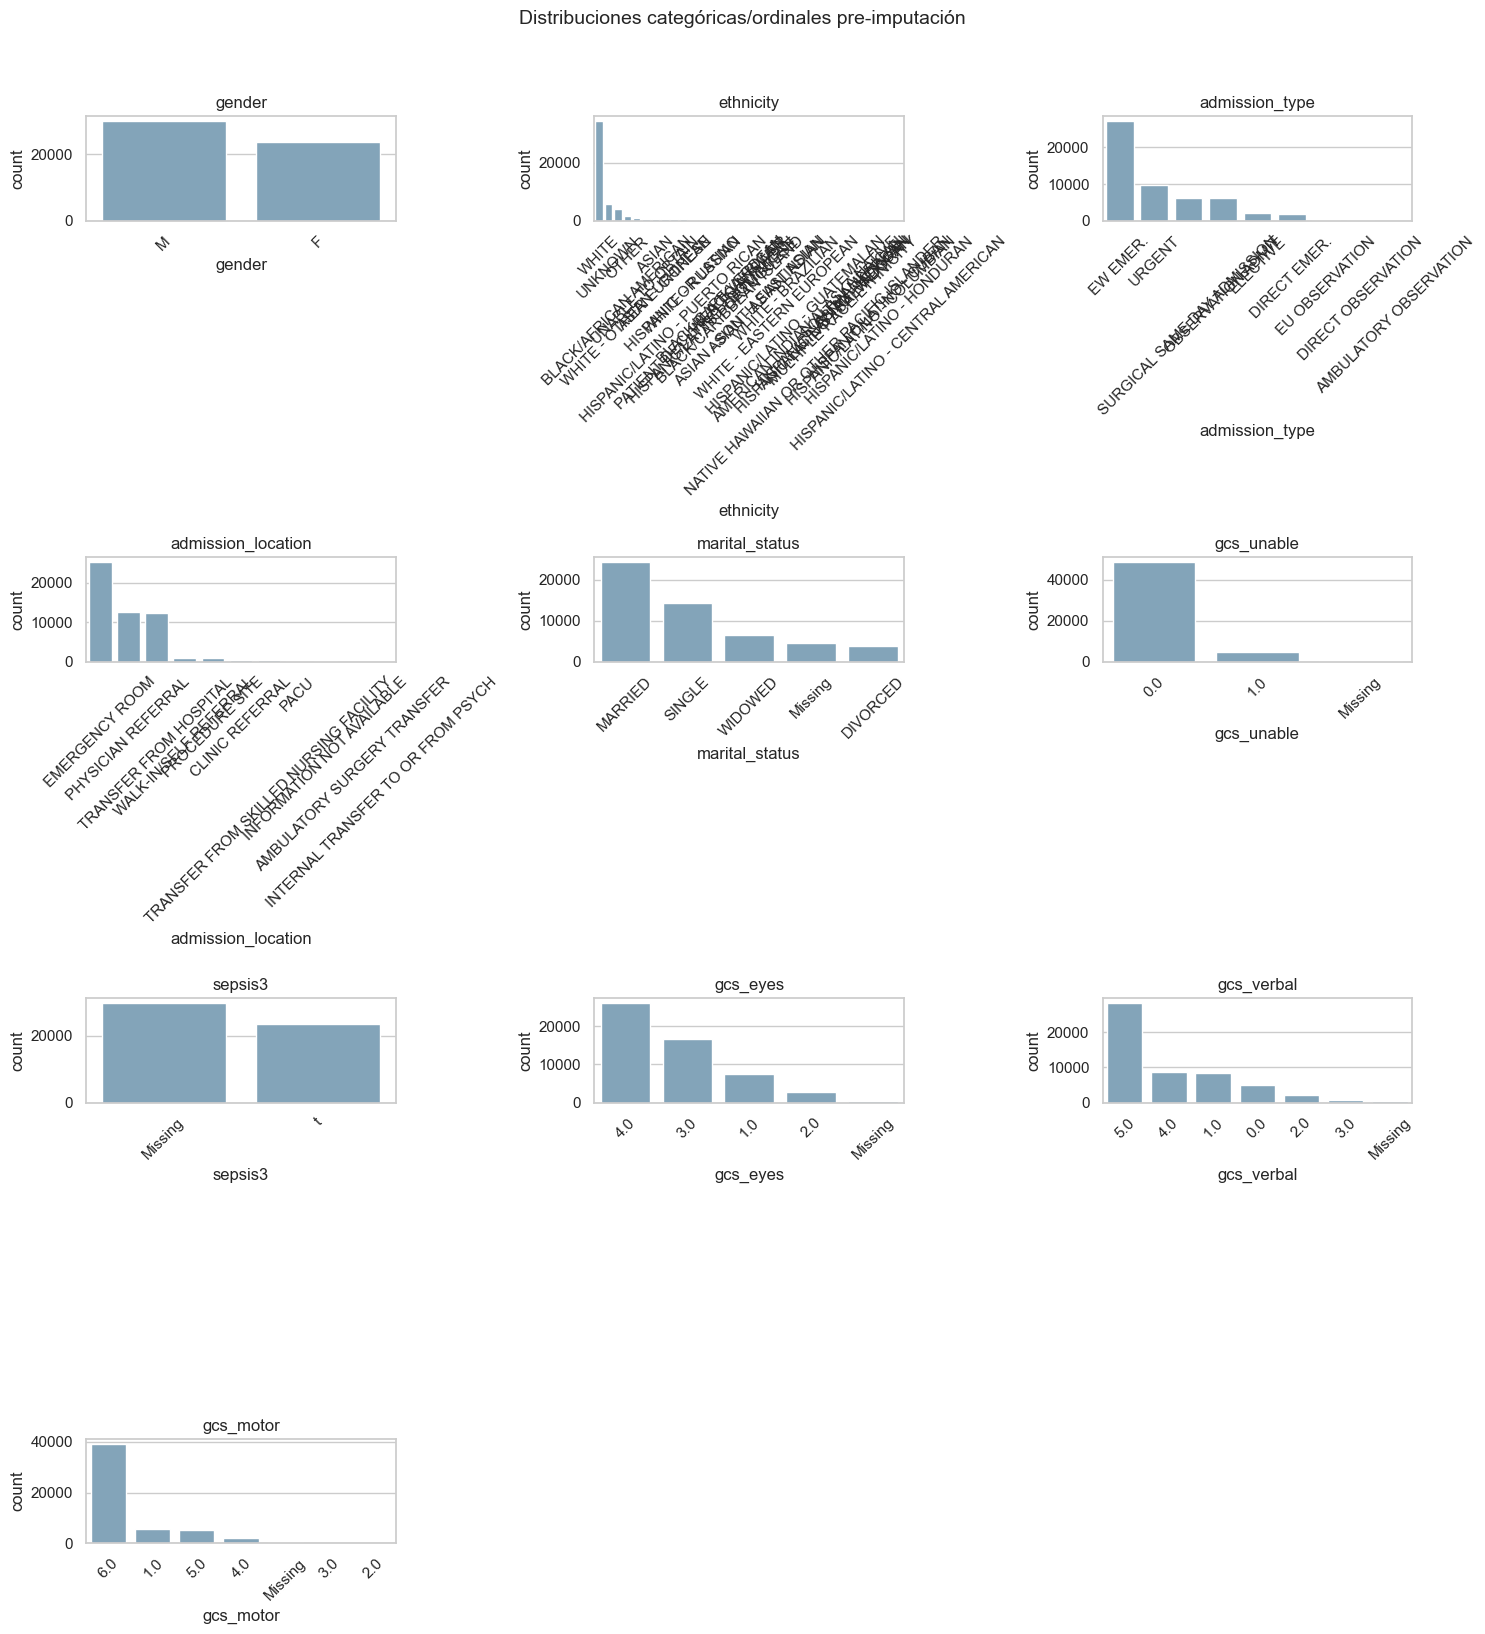

In [26]:
def _prepare_categorical_series(series: pd.Series) -> pd.Series:
    prepared = series.astype("object").where(series.notna(), "Missing")
    return prepared.astype(str)

def plot_categorical_grid(df: pd.DataFrame, columns: list[str], title: str, ncols: int = 3) -> None:
    available = [col for col in columns if col in df.columns]
    if not available:
        print("No hay variables categóricas disponibles.")
        return

    nrows = int(np.ceil(len(available) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, available):
        plot_df = df[[col]].copy()
        plot_df[col] = _prepare_categorical_series(plot_df[col])
        order = plot_df[col].value_counts(dropna=False).index.tolist()

        sns.countplot(
            data=plot_df,
            x=col,
            order=order,
            ax=ax,
            color="#7aa6c2",
        )
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(available):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_categorical_grid(
    raw_df,
    categorical_vars + ["gcs_eyes", "gcs_verbal", "gcs_motor"],
    "Distribuciones categóricas/ordinales pre-imputación",
)

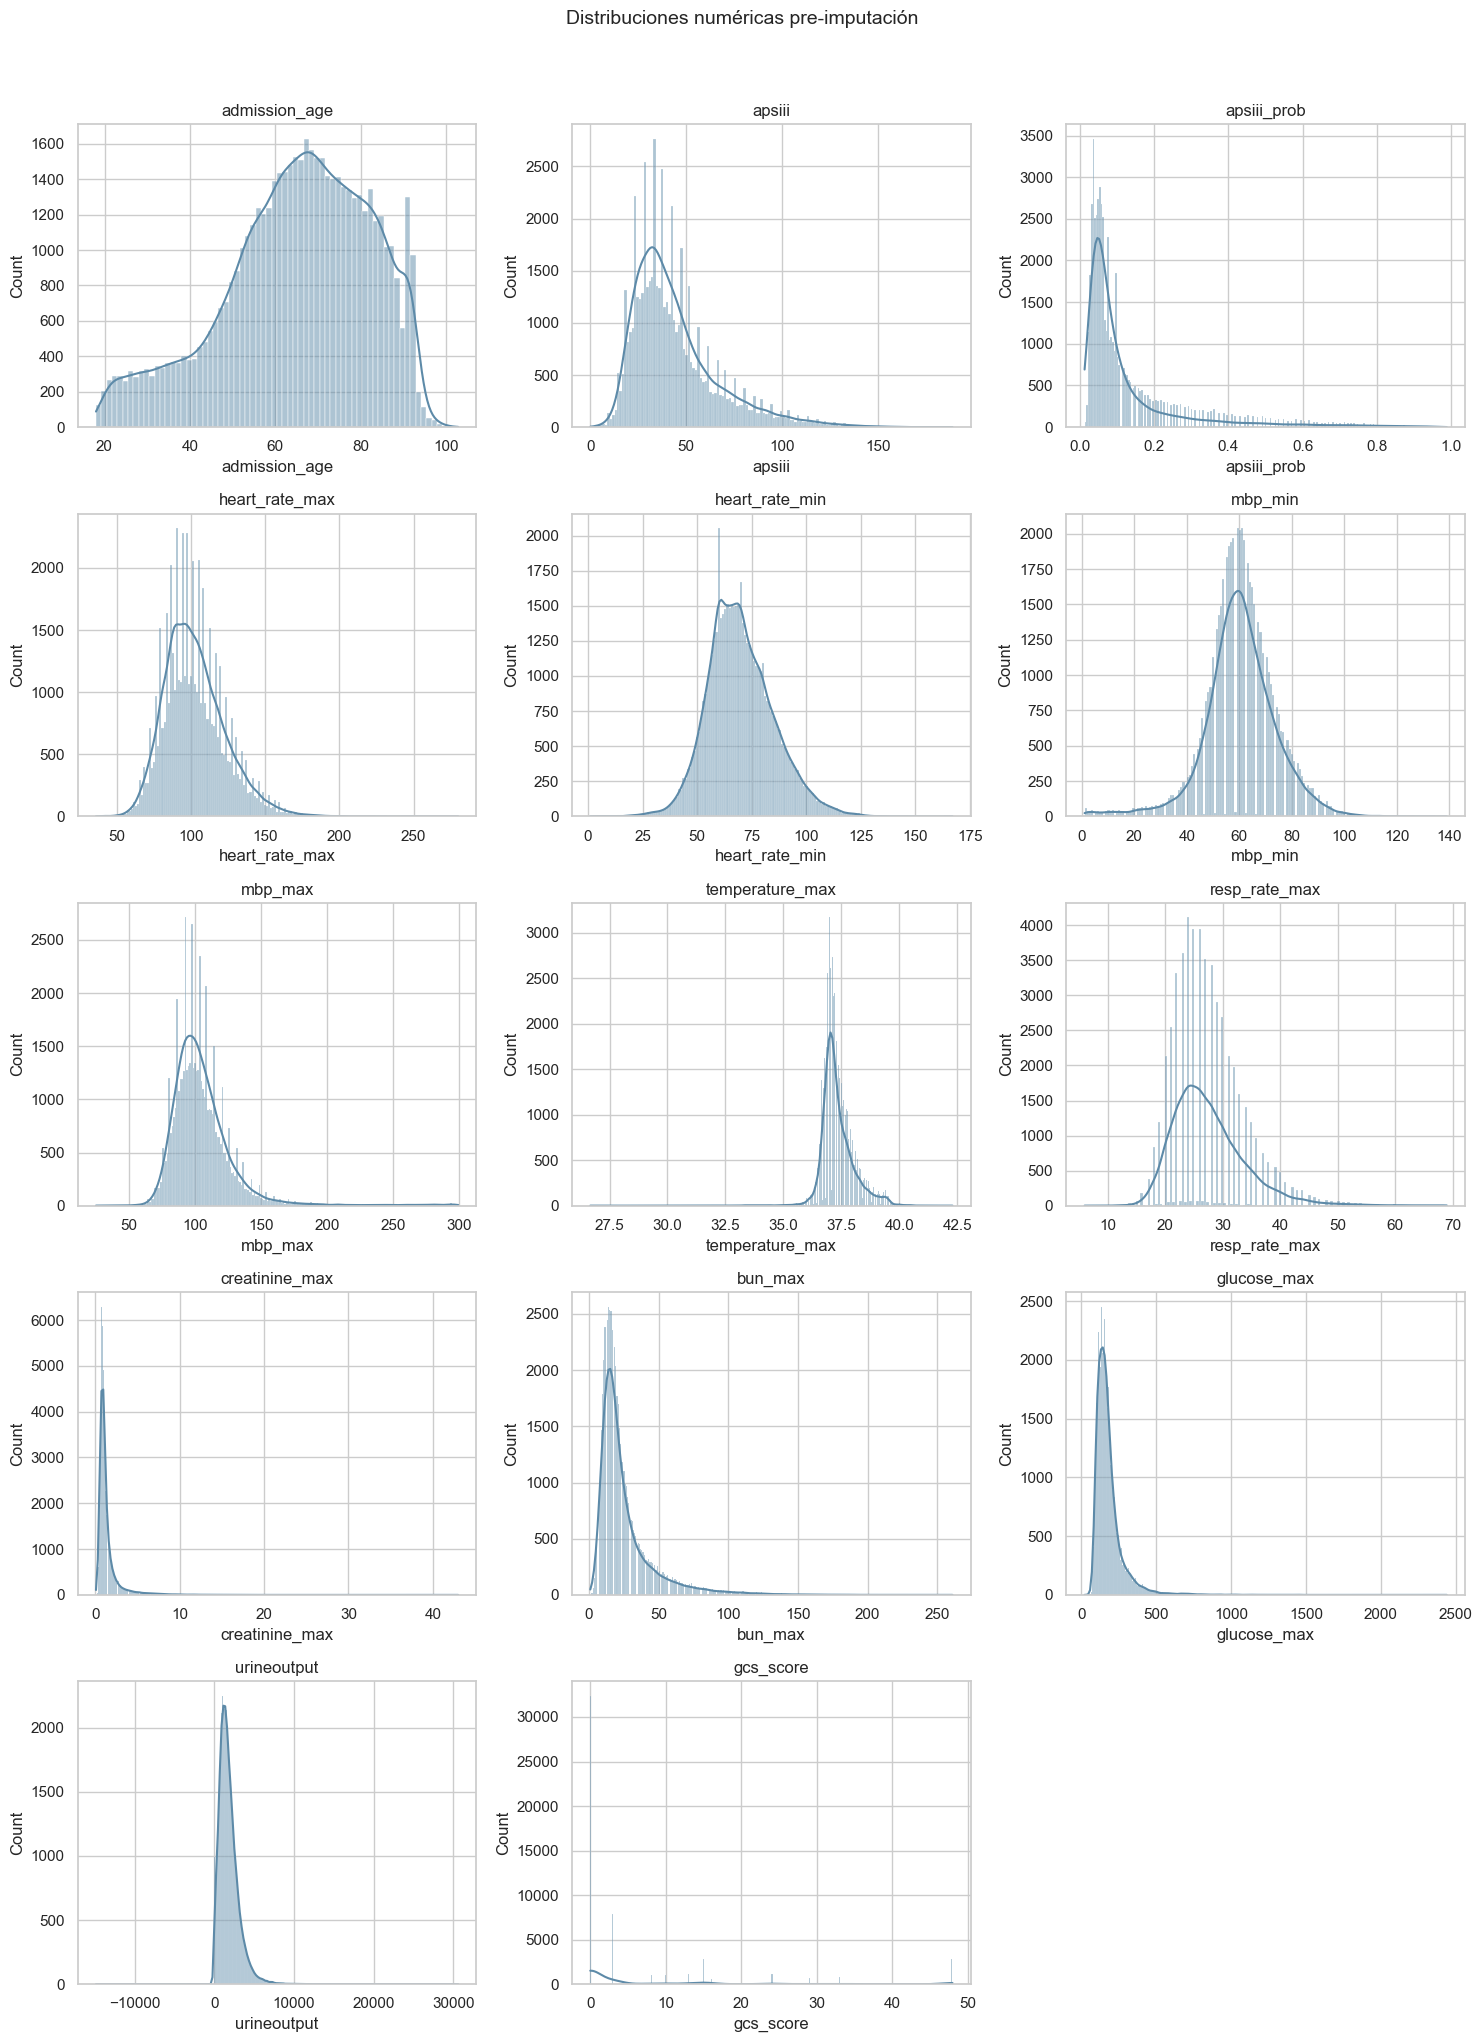

In [27]:
def plot_numeric_grid(df: pd.DataFrame, columns: list[str], title: str, ncols: int = 3) -> None:
    available = [col for col in columns if col in df.columns]
    if not available:
        print("No hay variables numéricas disponibles.")
        return

    nrows = int(np.ceil(len(available) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, available):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#5d8aa8")
        ax.set_title(col)

    for ax in axes[len(available):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_numeric_grid(raw_df, focus_numeric_vars, "Distribuciones numéricas pre-imputación")

### 3.2 Análisis bivariante en la base pre-imputación

En esta sección analizamos la relación de variables clave con la mortalidad hospitalaria y la estructura de asociación entre variables numéricas.

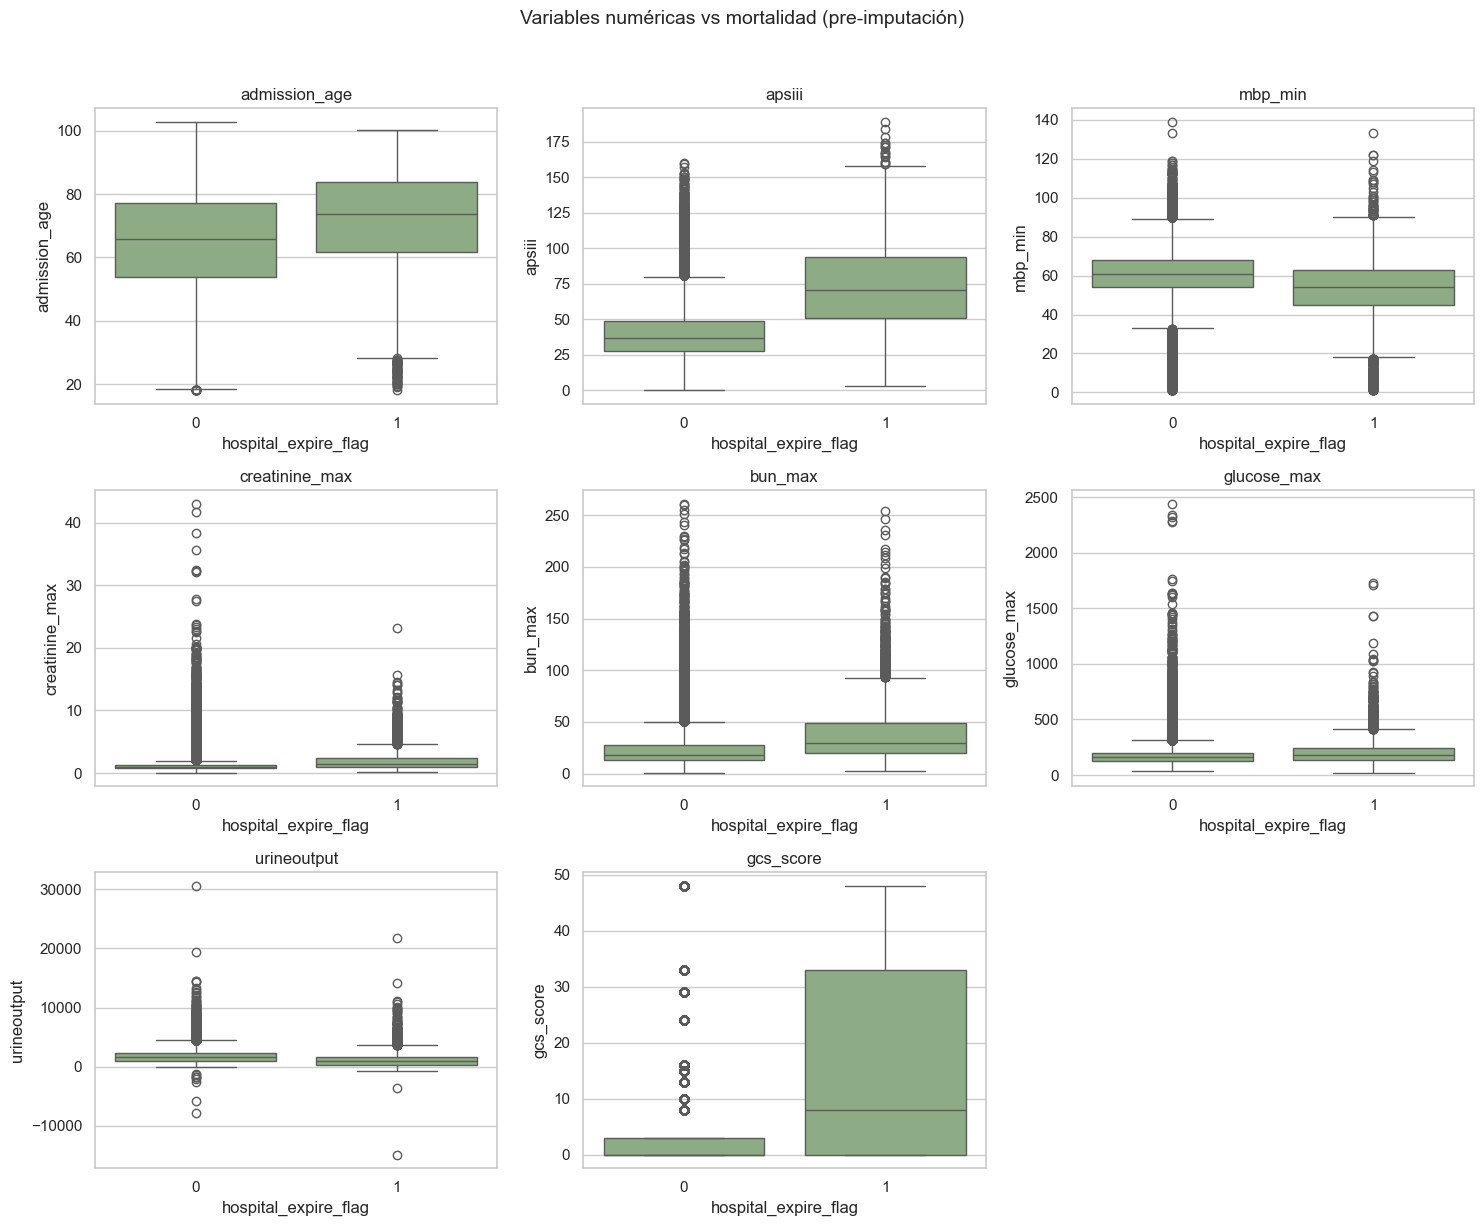

In [28]:
def plot_numeric_vs_target(df: pd.DataFrame, columns: list[str], target_col: str, title: str, ncols: int = 3) -> None:
    available = [col for col in columns if col in df.columns and target_col in df.columns]
    if not available:
        print("No hay variables disponibles para el análisis bivariante.")
        return

    nrows = int(np.ceil(len(available) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, available):
        sns.boxplot(data=df, x=target_col, y=col, ax=ax, color="#8ab17d")
        ax.set_title(col)
        ax.set_xlabel(target_col)

    for ax in axes[len(available):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

bivariate_numeric_focus = [
    "admission_age",
    "apsiii",
    "mbp_min",
    "creatinine_max",
    "bun_max",
    "glucose_max",
    "urineoutput",
    "gcs_score",
]

plot_numeric_vs_target(raw_df, bivariate_numeric_focus, TARGET_COL, "Variables numéricas vs mortalidad (pre-imputación)")

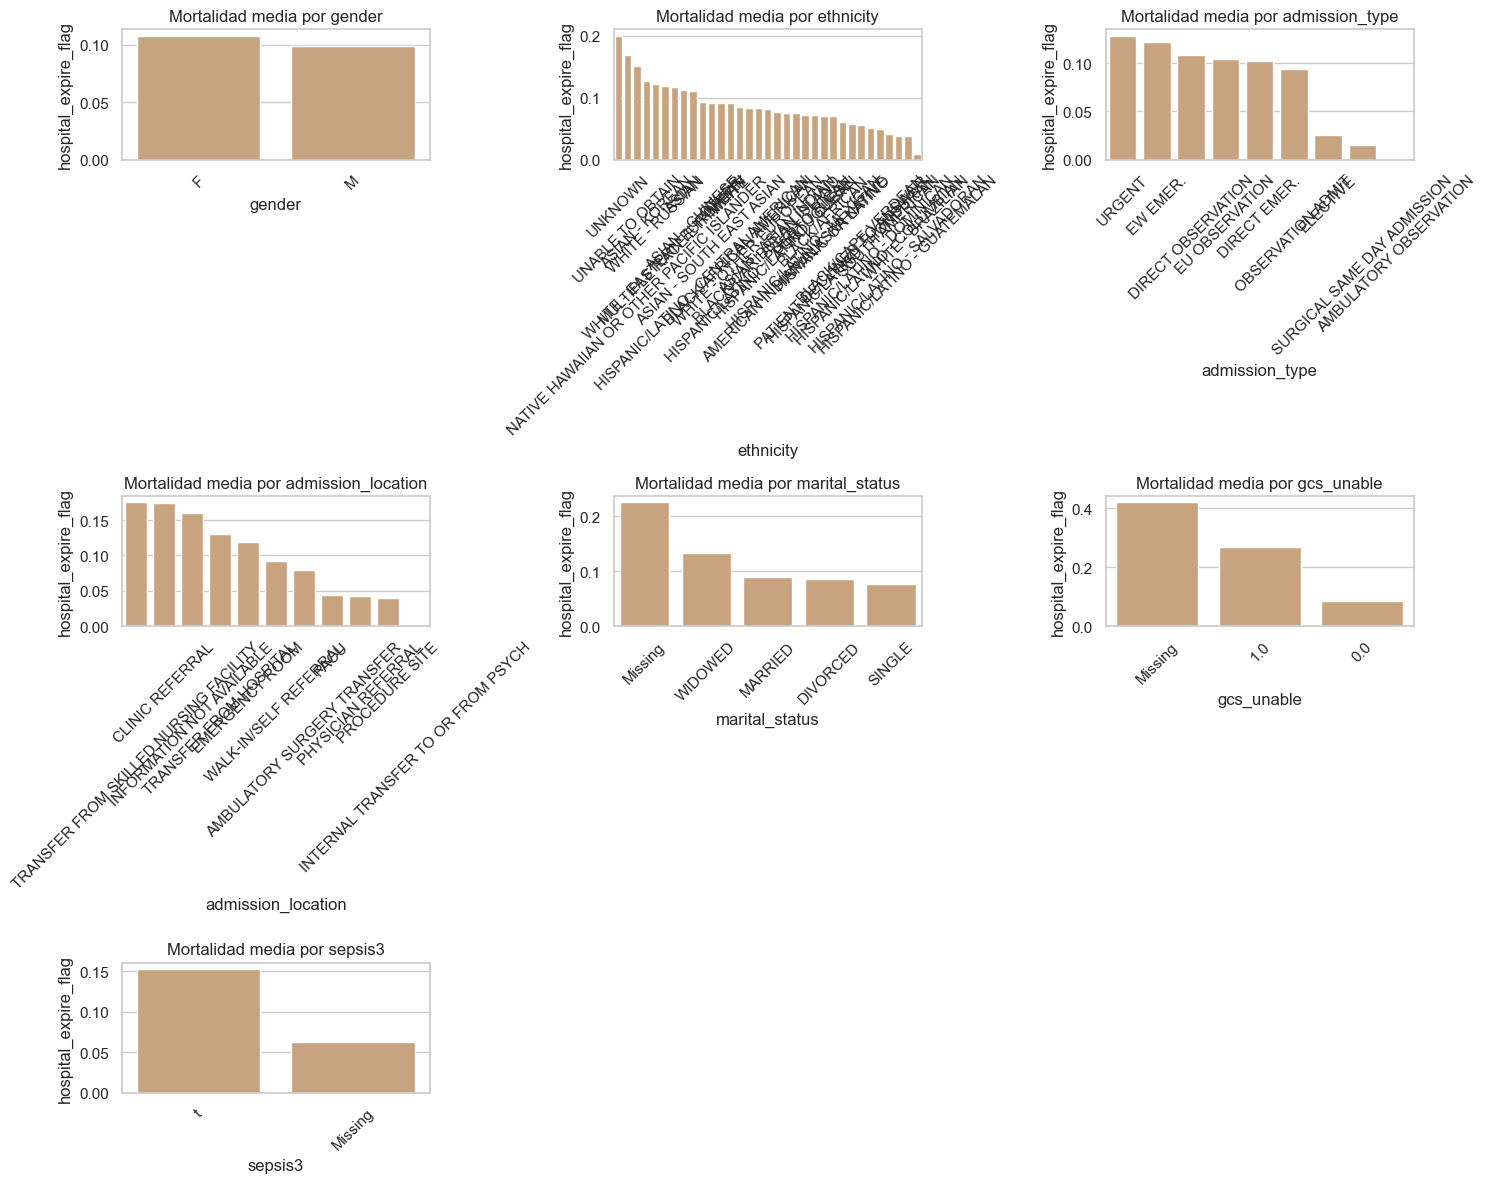

In [29]:
def plot_categorical_mortality(df: pd.DataFrame, columns: list[str], target_col: str, ncols: int = 3) -> None:
    available = [col for col in columns if col in df.columns and target_col in df.columns]
    if not available:
        print("No hay variables categóricas disponibles.")
        return

    nrows = int(np.ceil(len(available) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, available):
        plot_df = df[[col, target_col]].copy()
        plot_df[col] = _prepare_categorical_series(plot_df[col])

        rate_df = (
            plot_df.groupby(col, dropna=False)[target_col]
            .mean()
            .reset_index()
            .sort_values(target_col, ascending=False)
        )

        sns.barplot(
            data=rate_df,
            x=col,
            y=target_col,
            ax=ax,
            color="#d4a373",
        )
        ax.set_title(f"Mortalidad media por {col}")
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(available):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_categorical_mortality(raw_df, categorical_vars, TARGET_COL)

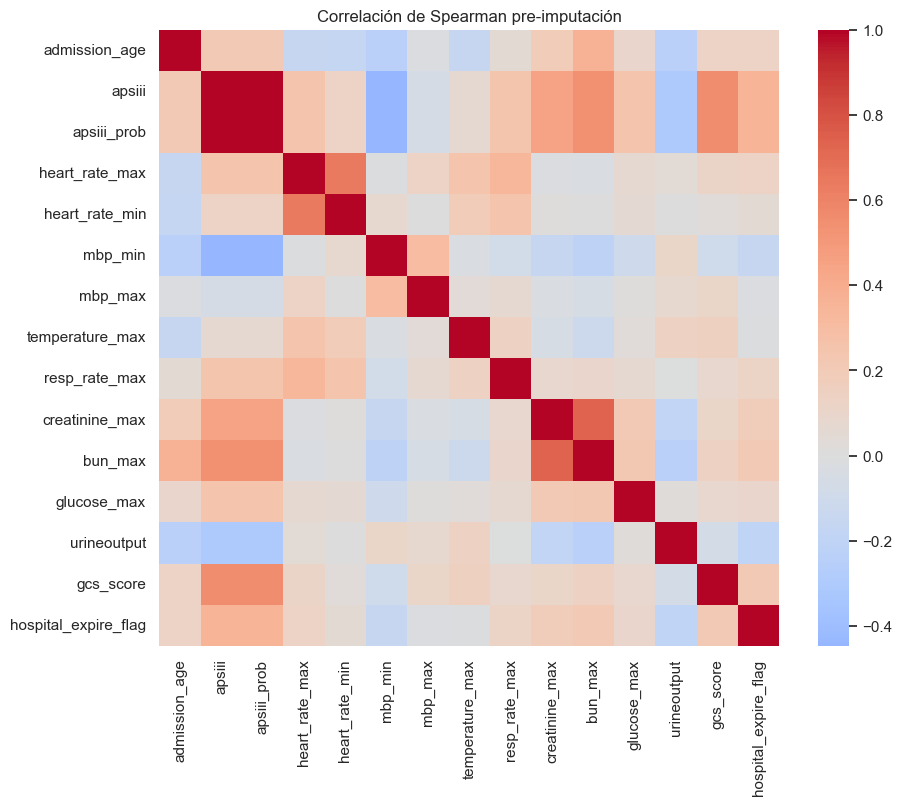

In [30]:
corr_vars_pre = [col for col in focus_numeric_vars if col in raw_df.columns]
corr_pre = raw_df[corr_vars_pre + [TARGET_COL]].corr(method="spearman", numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pre, cmap="coolwarm", center=0, annot=False)
plt.title("Correlación de Spearman pre-imputación")
plt.show()

## 4. Preprocesado e imputación

El objetivo de esta sección no es entrenar modelos, sino documentar qué cambia entre la base inicial y la base preparada. Aquí sí tiene sentido comparar ausencias y distribuciones entre la versión pre y la versión post, porque ambas representan etapas muy próximas del pipeline. Aun así, la comparación de ausencias se restringe a las variables seleccionadas para el EDA y excluye columnas posteriores al desenlace, ya que esas variables pueden quedar vacías por definición.

In [31]:
comparison_vars = [
    col for col in sorted(set(raw_selected).intersection(imputed_selected))
    if col not in POST_OUTCOME_COLUMNS
]

comparison = pd.DataFrame({"variable": comparison_vars})
comparison["missing_pre"] = comparison["variable"].map(raw_df[comparison_vars].isna().mean())
comparison["missing_post"] = comparison["variable"].map(imputed_df[comparison_vars].isna().mean())
comparison["diferencia_missing"] = comparison["missing_pre"] - comparison["missing_post"]

display(comparison.sort_values(["missing_pre", "missing_post"], ascending=False).head(15))

print(
    "Comparación de ausencias restringida a variables seleccionadas para el EDA y excluyendo columnas post-evento."
)

print(
    f"La base raw contiene {int(raw_df[comparison_vars].isna().sum().sum())} valores ausentes en las variables analizadas, "
    f"frente a {int(imputed_df[comparison_vars].isna().sum().sum())} en la base post-imputación."
)


,variable,missing_pre,missing_post,diferencia_missing
34,sepsis3,0.557468,0.0,0.557468
27,marital_status,0.086916,0.0,0.086916
38,temp_score,0.032295,0.0,0.032295
39,temperature_max,0.032295,0.0,0.032295
40,temperature_min,0.032295,0.0,0.032295
41,uo_score,0.030167,0.0,0.030167
42,urineoutput,0.030167,0.0,0.030167
14,gcs_score,0.021598,0.0,0.021598
35,sodium_max,0.011873,0.0,0.011873
36,sodium_min,0.011873,0.0,0.011873


Comparación de ausencias restringida a variables seleccionadas para el EDA y excluyendo columnas post-evento.
La base raw contiene 55208 valores ausentes en las variables analizadas, frente a 0 en la base post-imputación.


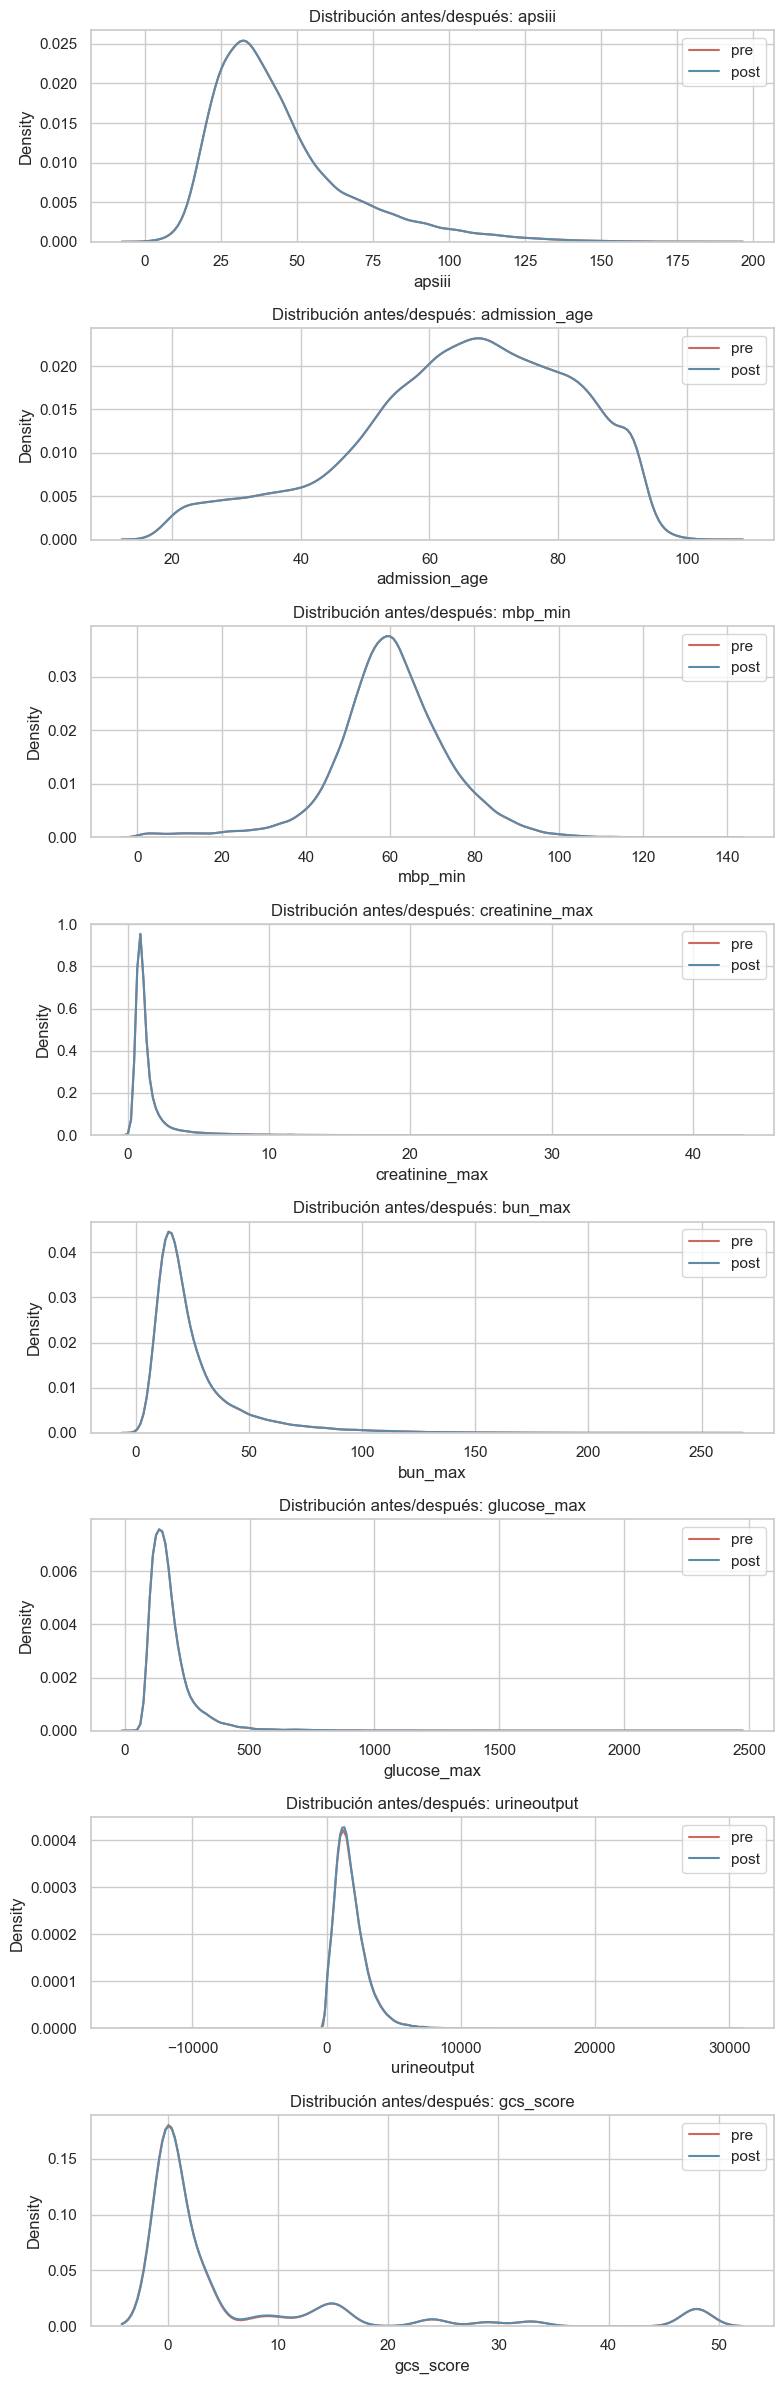

In [32]:
compare_distribution_vars = [
    "apsiii",
    "admission_age",
    "mbp_min",
    "creatinine_max",
    "bun_max",
    "glucose_max",
    "urineoutput",
    "gcs_score",
]

available_compare_vars = [col for col in compare_distribution_vars if col in raw_df.columns and col in imputed_df.columns]

fig, axes = plt.subplots(len(available_compare_vars), 1, figsize=(8, 3 * len(available_compare_vars)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, available_compare_vars):
    sns.kdeplot(raw_df[col].dropna(), ax=ax, label="pre", color="#c96b5c")
    sns.kdeplot(imputed_df[col].dropna(), ax=ax, label="post", color="#5d8aa8")
    ax.set_title(f"Distribución antes/después: {col}")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. EDA después del preprocesado e imputación

Una vez revisada la transición entre bases, repetimos el análisis exploratorio en la base resultante para describir las variables con las que posteriormente se trabajará en la fase predictiva.

In [33]:
imputed_missing = (
    imputed_df[imputed_selected]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "variable"})
)

imputed_missing.head(15)

,variable,missing_pct
0,gender,0.0
1,admission_age,0.0
2,ethnicity,0.0
3,admission_type,0.0
4,admission_location,0.0
5,marital_status,0.0
6,gcs_unable,0.0
7,sepsis3,0.0
8,apsiii,0.0
9,apsiii_prob,0.0


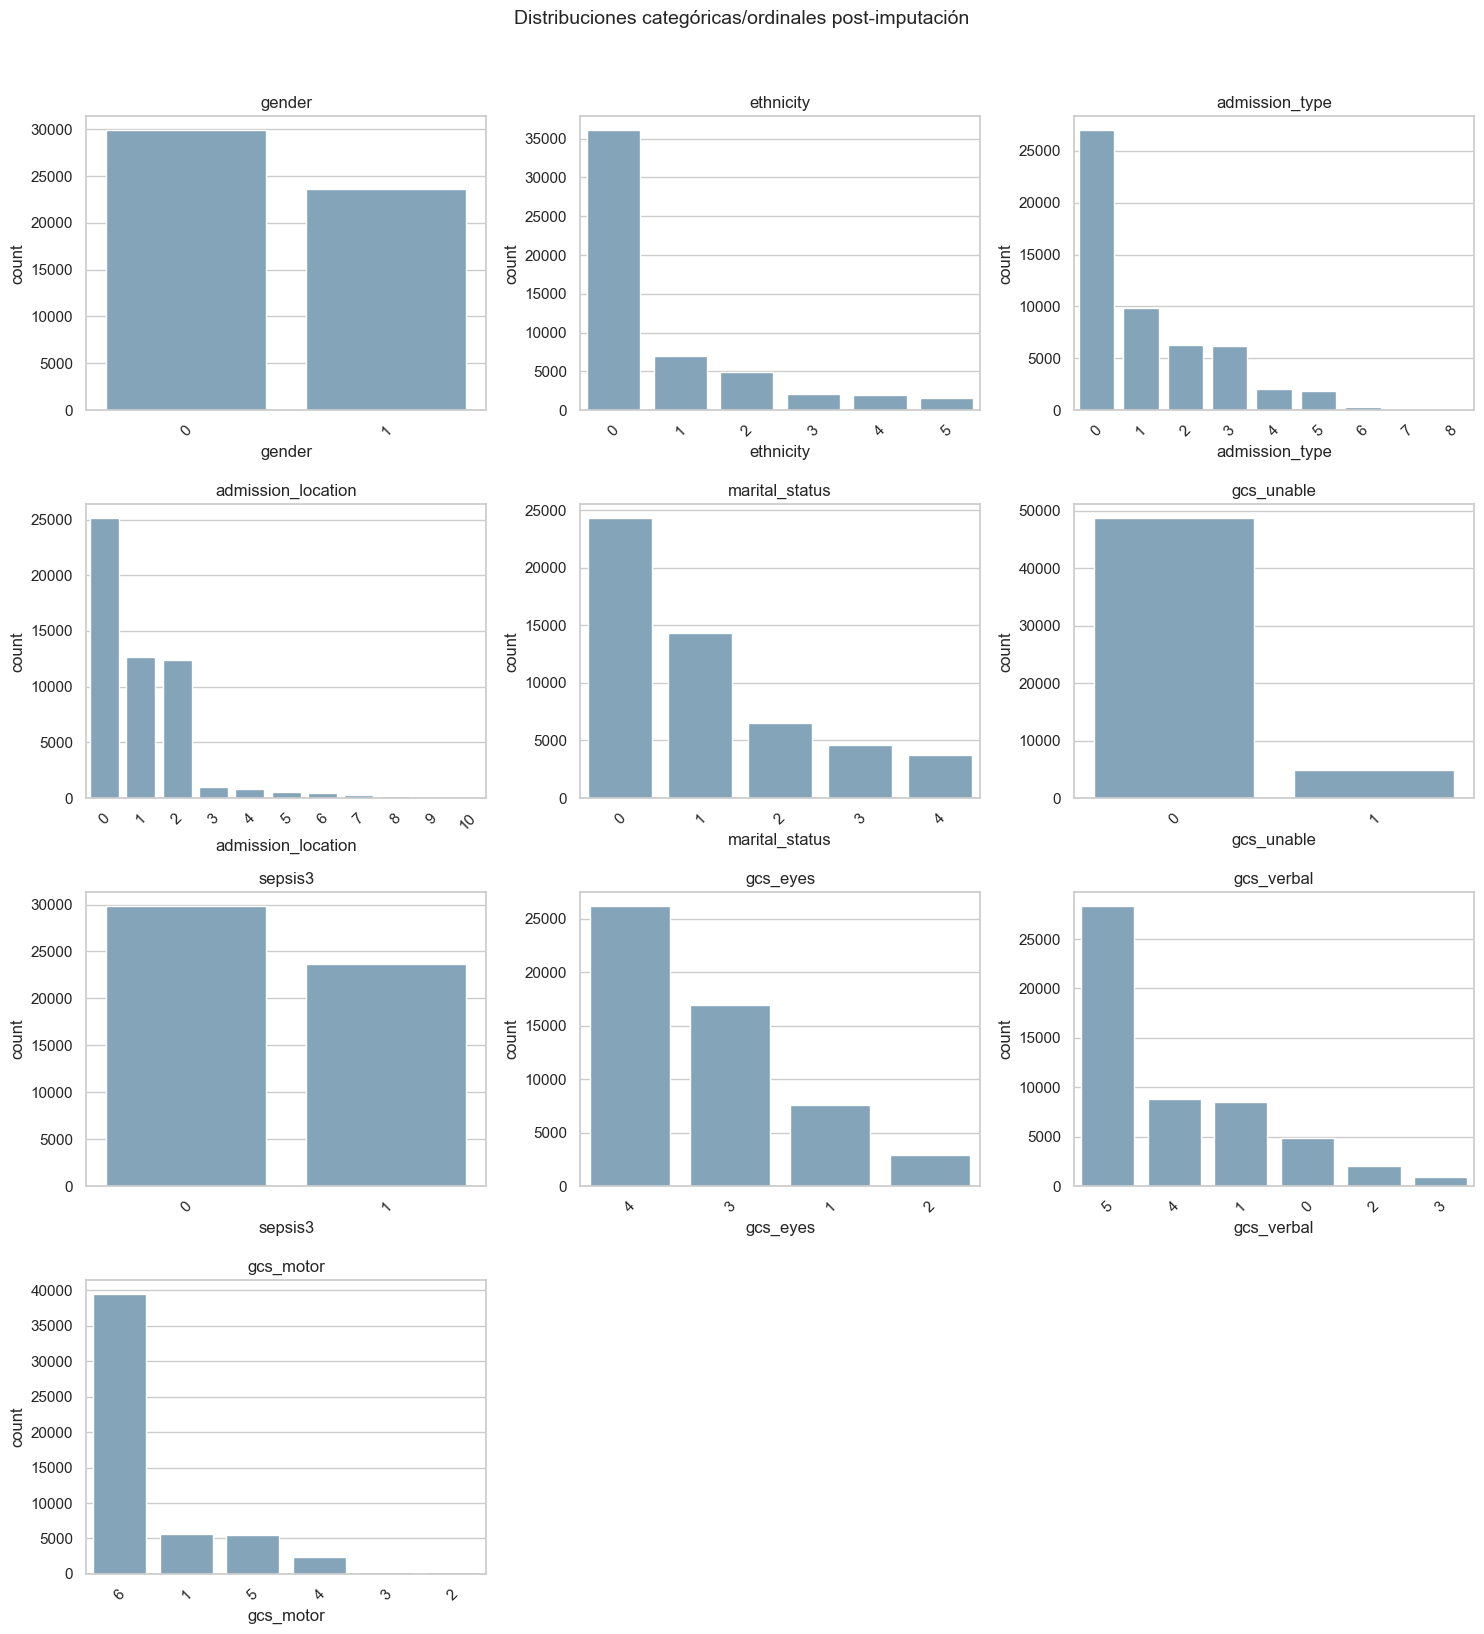

In [34]:
plot_categorical_grid(
    imputed_df,
    categorical_vars + ["gcs_eyes", "gcs_verbal", "gcs_motor"],
    "Distribuciones categóricas/ordinales post-imputación",
)

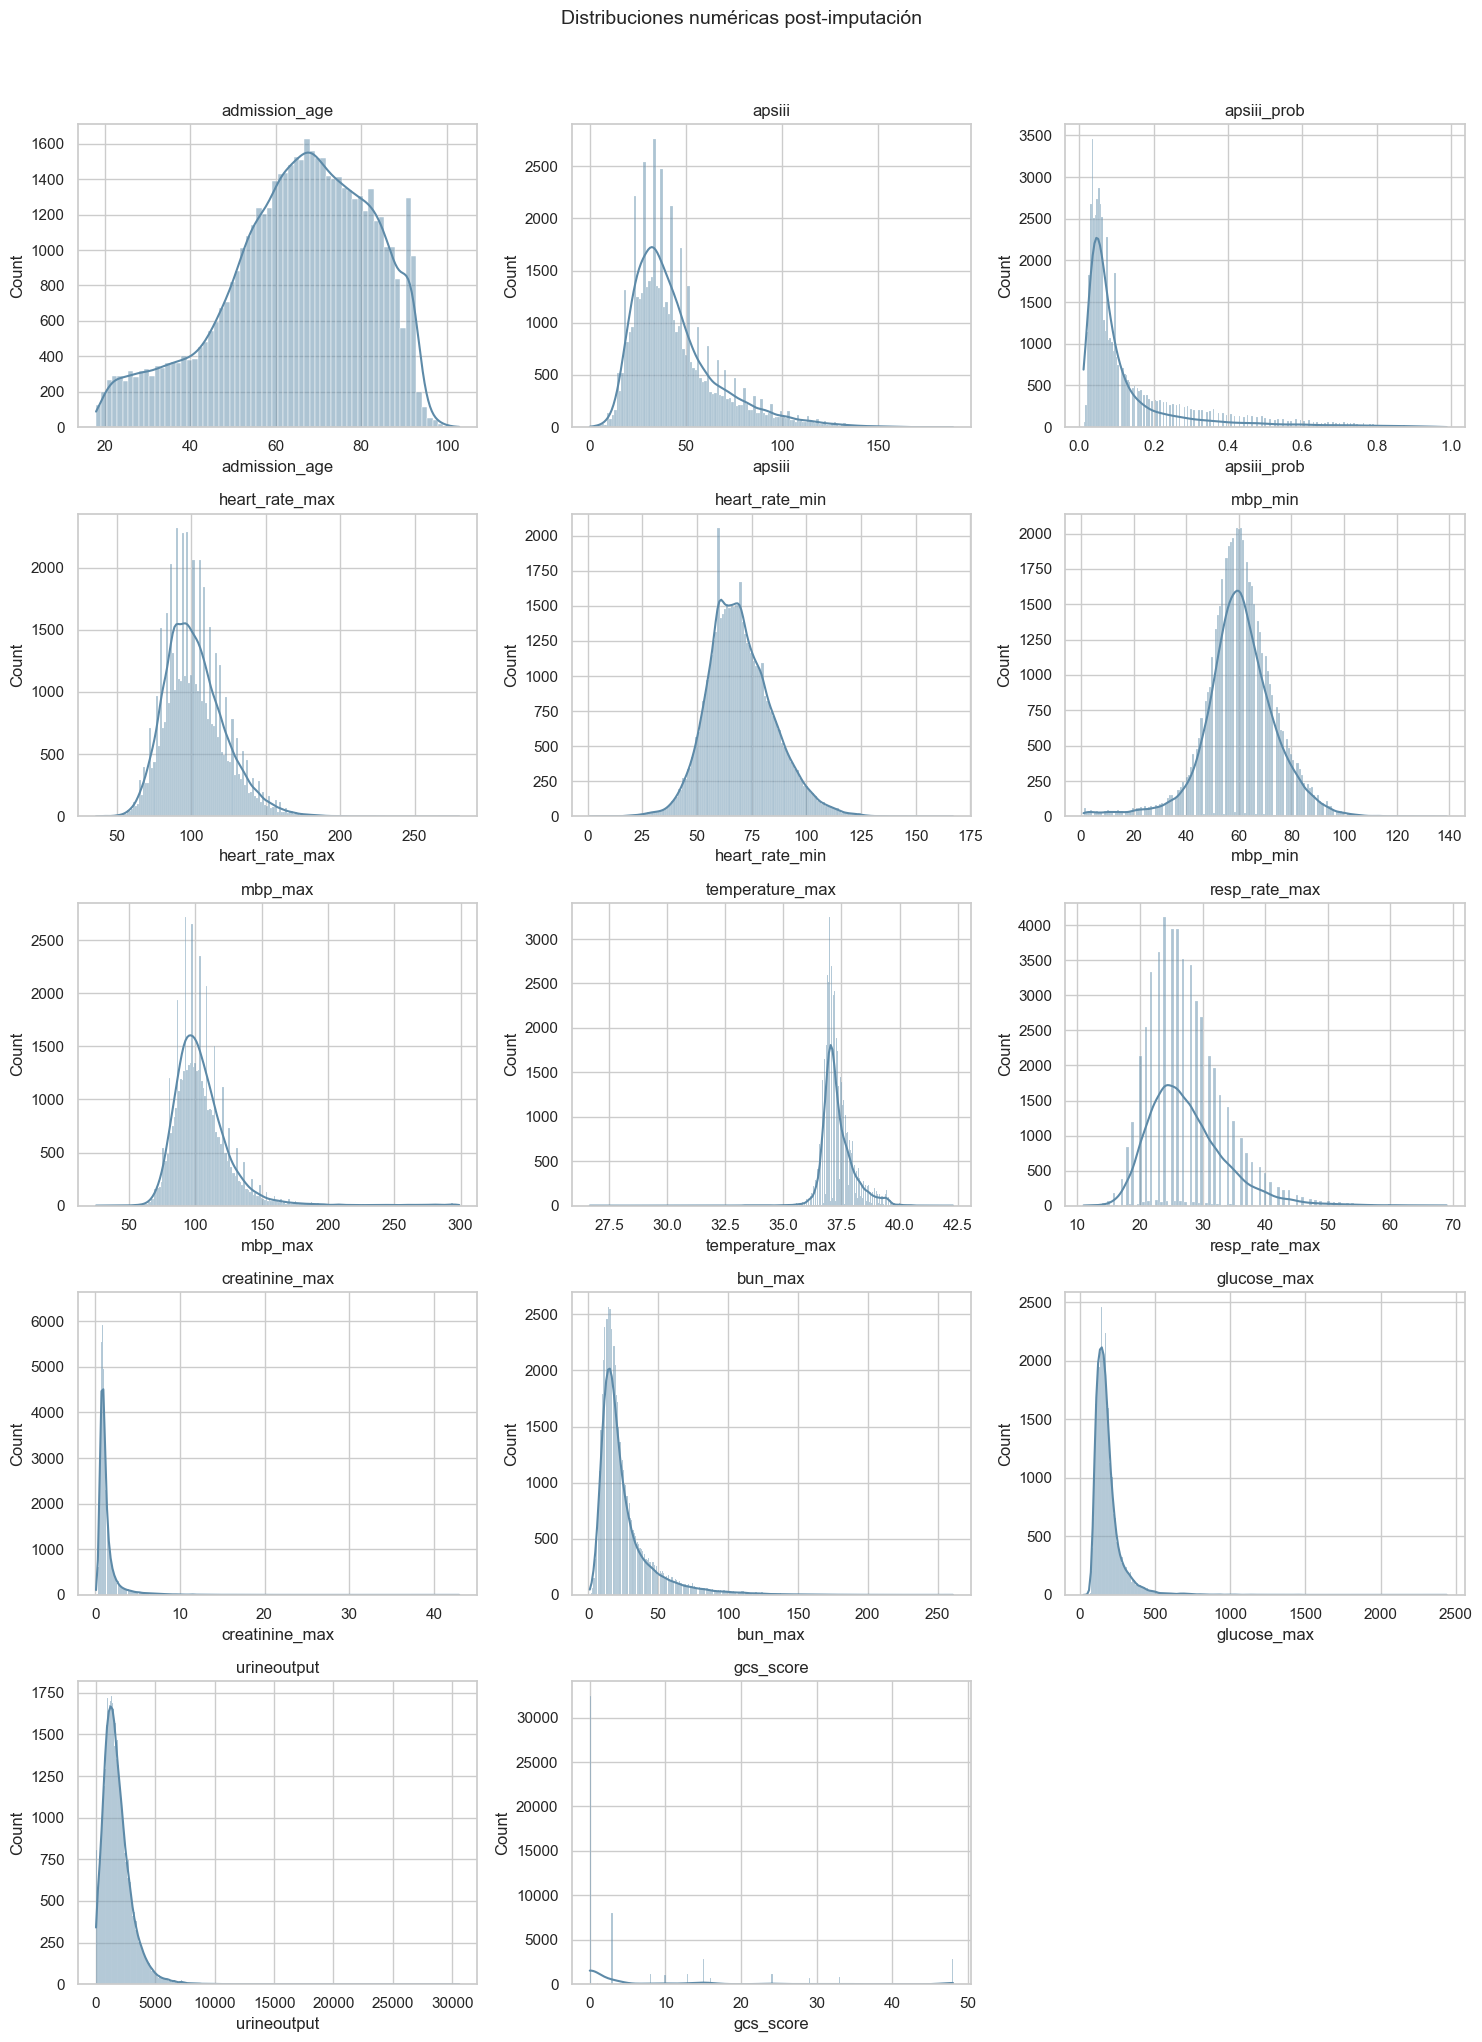

In [35]:
plot_numeric_grid(imputed_df, focus_numeric_vars, "Distribuciones numéricas post-imputación")

### 5.1 Análisis bivariante en la base post-imputación

Este bloque permite describir mejor la base final que alimentará las siguientes fases del proyecto, manteniendo el enfoque en patrones clínicos y separación respecto al desenlace.

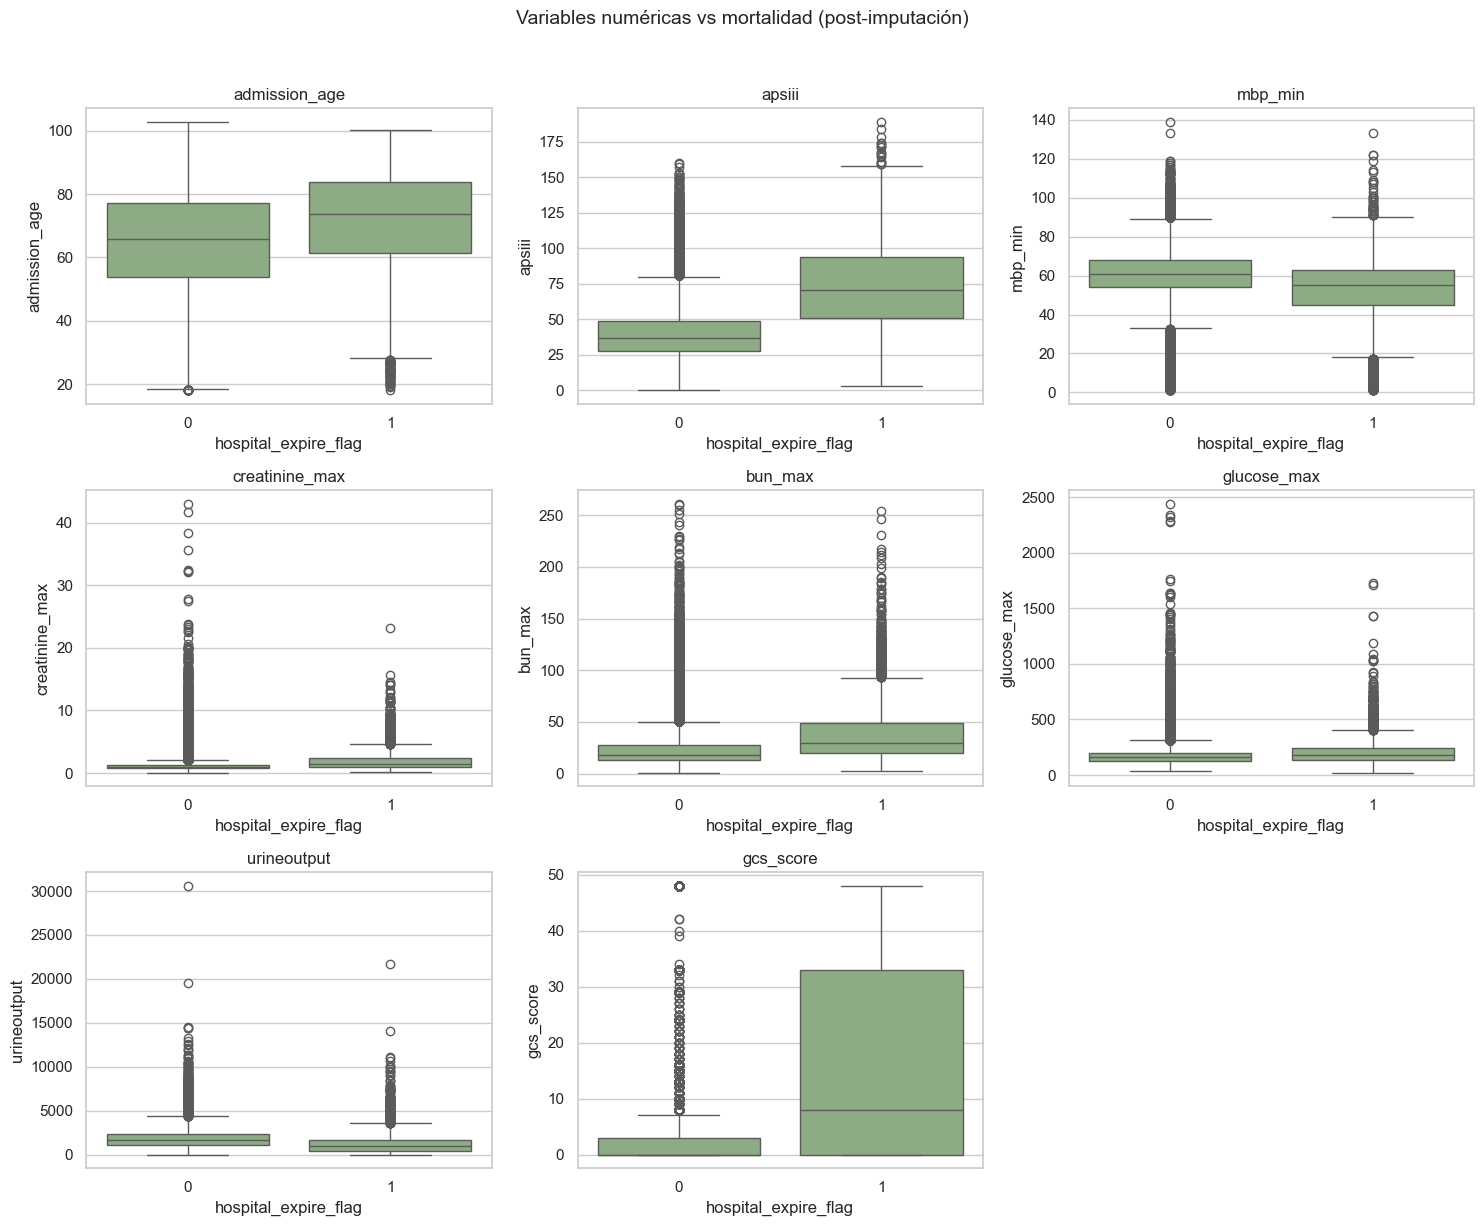

In [36]:
plot_numeric_vs_target(
    imputed_df,
    bivariate_numeric_focus,
    TARGET_COL,
    "Variables numéricas vs mortalidad (post-imputación)",
)

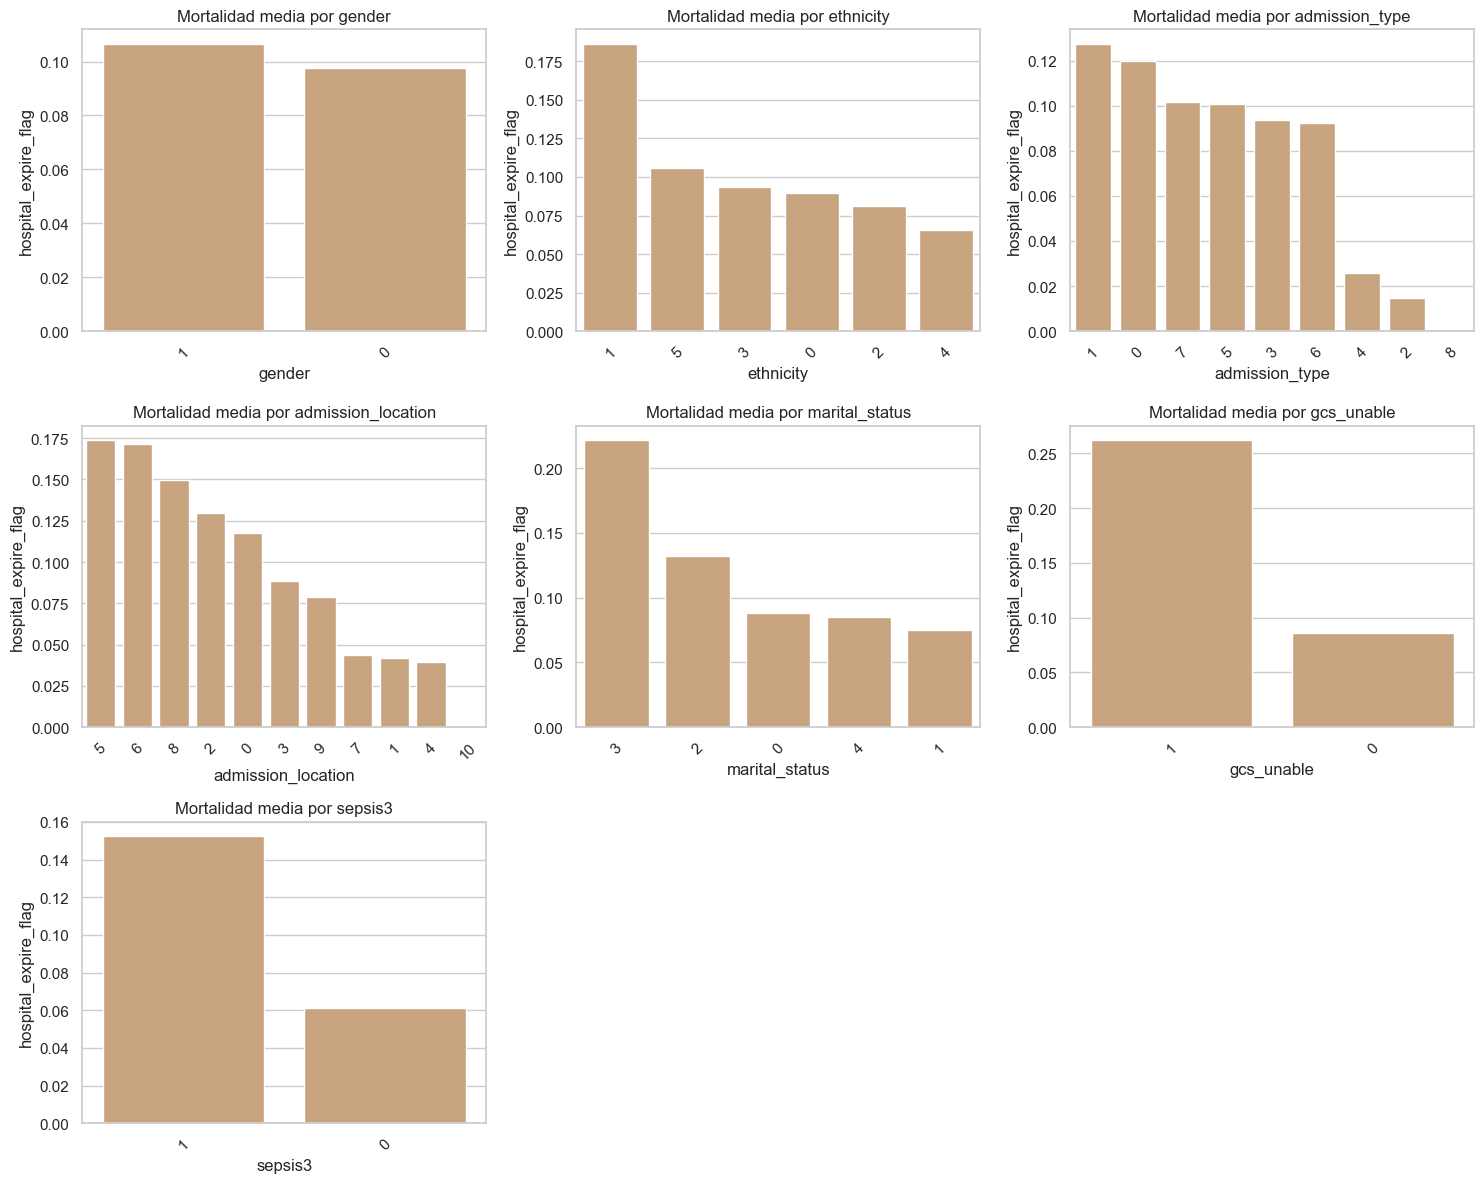

In [37]:
plot_categorical_mortality(imputed_df, categorical_vars, TARGET_COL)

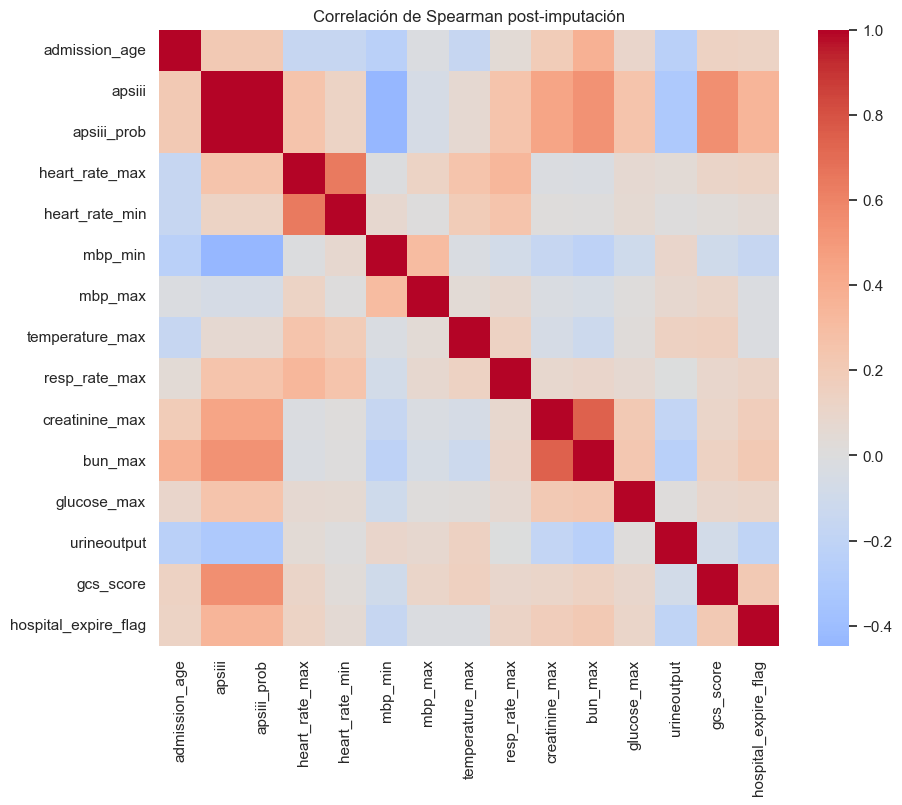

In [38]:
corr_vars_post = [col for col in focus_numeric_vars if col in imputed_df.columns]
corr_post = imputed_df[corr_vars_post + [TARGET_COL]].corr(method="spearman", numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_post, cmap="coolwarm", center=0, annot=False)
plt.title("Correlación de Spearman post-imputación")
plt.show()

## 6. Conclusiones del EDA

A partir de este notebook, las conclusiones del informe pueden organizarse así:

- **Base inicial**: calidad del dato, estructura, presencia de ausencias y comportamiento general de variables clínicas relevantes.
- **Antes del modelado**: comparación entre la base inicial y la base procesada para justificar la necesidad de imputación y del preprocesado aplicado.
- **Base final para análisis posteriores**: distribución y relación con la mortalidad de las variables priorizadas para la fase predictiva.